# 데이터 현황 요약

| 항목 | 내용 |
|------|------|
| 행/열 | 13,431행 × 36열 |
| 결측치 | 없음 (클린) |
| 타겟 | `현재가격_만원` (mean: 1,955만 / max: 9,998만) |
| 제거 대상 | `매물ID`, `모델` (ID/카테고리 원본) |
| 수치형 피처 | 주행거리, 배기량, 좌석수, 차량연령, 사고강도점수 |
| 이진 피처 | 주요옵션 10개 + 제조사 6개 + 연료 5개 + 색상 4개 + 변속기 + 차급 2개 = 28개 |

# 중고차 가격 예측 모델 프로세스

Phase 1 — EDA (탐색적 분석)
- 타겟 분포 확인 (skewness, 이상치)
- 수치형 피처 vs 타겟 상관관계
- 차량연령 / 주행거리 / 모델_평균가_TE 영향도 시각화
- 제조사·연료·차급별 가격 분포 비교

Phase 2 — 전처리
- `매물ID`, `모델` 컬럼 제거
- 타겟 로그변환 여부 검토 (우편향 분포)
- Train/Test split (8:2 또는 시계열 고려시 조정)

Phase 3 — 베이스라인 모델
- Linear Regression (기준선)
- Ridge / Lasso (정규화)
- Random Forest

Phase 4 — 주력 모델 튜닝
- **XGBoost / LightGBM / CatBoost** 비교 실험
- Optuna 또는 GridSearchCV로 하이퍼파라미터 튜닝
- Cross-validation (KFold 5)

Phase 5 — 모델 평가 & 해석
- 지표: RMSE, MAE, R², MAPE
- Feature Importance (SHAP values)
- 잔차 분석 (어떤 가격대에서 오차 큰지)

Phase 6 — 앙상블 (선택)
- Stacking 또는 Blending
- 최종 모델 선정

# Phase 1 — EDA (탐색적 분석)

In [1]:
# ============================================================
# 중고차 판매가격 예측 모델 - 1단계: 탐색적 데이터 분석 (EDA)
# ============================================================

# 0. 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"pandas {pd.__version__} / numpy {np.__version__}")

# 1. 데이터 불러오기
DATA_PATH = r"C:\Users\Admin\hipython\ml\bermuda.project\encar_kia_all\output\encar_feature_processed_with_model_avg_te.csv"

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f"데이터 로드 완료: {df.shape[0]:,}행 × {df.shape[1]}열")
df.head()


pandas 2.3.3 / numpy 2.4.2
데이터 로드 완료: 11,617행 × 38열


,매물ID,모델,모델_평균가_TE,현재가격_만원,주행거리_km,배기량_cc,좌석수,차량연령,사고강도점수,주요옵션_선루프,...,연료_디젤,연료_전기,연료_수소,색상_흰색,색상_검정색,색상_은색,색상_기타,변속기_오토계열,차급_SUV계열,차급_세단계열
0,37398208.0,렉스턴 스포츠 칸,2113.842105,1700.0,92801,2157,5,7,10,0,...,1,0,0,0,0,0,1,1,1,0
1,37424561.0,코란도 투리스모,658.918367,750.0,118621,2157,5,10,6,0,...,1,0,0,0,1,0,0,1,1,0
2,38020327.0,티볼리 에어,1023.075269,650.0,120313,1597,5,10,2,0,...,1,0,0,1,0,0,0,1,1,0
3,38261140.0,코란도 투리스모,658.918367,650.0,82255,1998,5,12,5,1,...,1,0,0,1,0,0,0,1,1,0
4,38349931.0,G4 렉스턴,1783.857143,1670.0,93678,2157,5,9,11,1,...,1,0,0,0,1,0,0,1,1,0


In [2]:
# 2. 기본 정보 확인
print("=" * 60)
print("【 컬럼 목록 및 데이터 타입 】")
print("=" * 60)
print(df.dtypes)
print(f"\n총 결측치: {df.isnull().sum().sum()}")

【 컬럼 목록 및 데이터 타입 】
매물ID               float64
모델                  object
모델_평균가_TE          float64
현재가격_만원            float64
주행거리_km              int64
배기량_cc               int64
좌석수                  int64
차량연령                 int64
사고강도점수               int64
주요옵션_선루프             int64
주요옵션_헤드램프 (LED)      int64
주요옵션_주차감지센서          int64
주요옵션_후방카메라           int64
주요옵션_자동에어컨           int64
주요옵션_스마트키            int64
주요옵션_내비게이션           int64
주요옵션_열선시트            int64
주요옵션_통풍시트            int64
주요옵션_가죽시트            int64
제조사_현대               int64
제조사_기아               int64
제조사_제네시스             int64
제조사_KG모빌리티(쌍용)       int64
제조사_쉐보레(GM대우)        int64
제조사_르노코리아(삼성)        int64
연료_LPG               int64
연료_가솔린               int64
연료_하이브리드             int64
연료_디젤                int64
연료_전기                int64
연료_수소                int64
색상_흰색                int64
색상_검정색               int64
색상_은색                int64
색상_기타                int64
변속기_오토계열             int64
차급_SUV계열 

In [3]:
# 3. 수치형 변수 기술통계
# 이진형(0/1) 변수 제외, 연속형만
binary_cols = [c for c in df.columns if df[c].nunique() == 2 and set(df[c].dropna().unique()) <= {0, 1}]
continuous_cols = [c for c in df.select_dtypes(include='number').columns
                   if c not in binary_cols and c != '매물ID']

print("【 연속형 변수 목록 】")
print(continuous_cols)

print("\n【 기술통계 】")
desc = df[continuous_cols].describe().T
desc['skewness'] = df[continuous_cols].skew().round(3)
desc['kurtosis'] = df[continuous_cols].kurt().round(3)
desc

【 연속형 변수 목록 】
['모델_평균가_TE', '현재가격_만원', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수']

【 기술통계 】


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
모델_평균가_TE,11617.0,2082.699320,1358.871713,140.0,935.108571,1818.07027,3116.777049,7468.25,0.817,0.145
현재가격_만원,11617.0,2082.699320,1698.301935,1.0,829.000000,1679.00000,2800.000000,12590.00,1.889,5.071
주행거리_km,11617.0,92198.832831,56053.984981,1.0,49230.000000,85639.00000,127884.000000,429407.00,0.740,0.710
배기량_cc,11617.0,2100.557717,781.305282,0.0,1598.000000,1998.00000,2497.000000,6162.00,0.549,1.561
좌석수,11617.0,5.416889,1.334151,2.0,5.000000,5.00000,5.000000,16.00,2.890,11.754
차량연령,11617.0,7.351898,3.992842,0.0,4.000000,7.00000,10.000000,38.00,0.759,1.261
사고강도점수,11617.0,3.879745,4.559099,0.0,1.000000,2.00000,6.000000,36.00,1.828,4.042


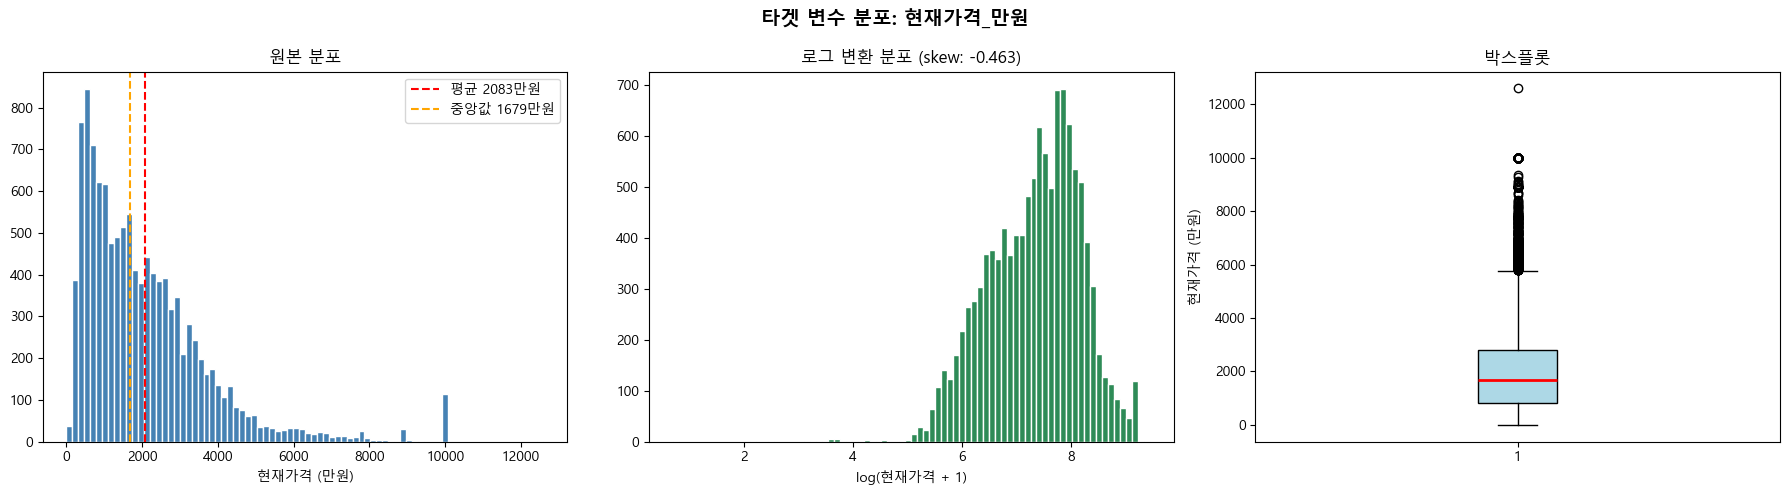

왜도: 1.8887 / 첨도: 5.0706


In [4]:
# 4. 타겟 변수 분포
target = '현재가격_만원'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타겟 변수 분포: 현재가격_만원', fontsize=14, fontweight='bold')

# 원본 분포
axes[0].hist(df[target], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(df[target].mean(), color='red', linestyle='--', label=f'평균 {df[target].mean():.0f}만원')
axes[0].axvline(df[target].median(), color='orange', linestyle='--', label=f'중앙값 {df[target].median():.0f}만원')
axes[0].set_title('원본 분포')
axes[0].set_xlabel('현재가격 (만원)')
axes[0].legend()

# 로그 변환 분포
axes[1].hist(np.log1p(df[target]), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title(f'로그 변환 분포 (skew: {np.log1p(df[target]).skew():.3f})')
axes[1].set_xlabel('log(현재가격 + 1)')

# 박스플롯
axes[2].boxplot(df[target], patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('박스플롯')
axes[2].set_ylabel('현재가격 (만원)')

plt.tight_layout()
plt.show()

print(f"왜도: {df[target].skew():.4f} / 첨도: {df[target].kurt():.4f}")

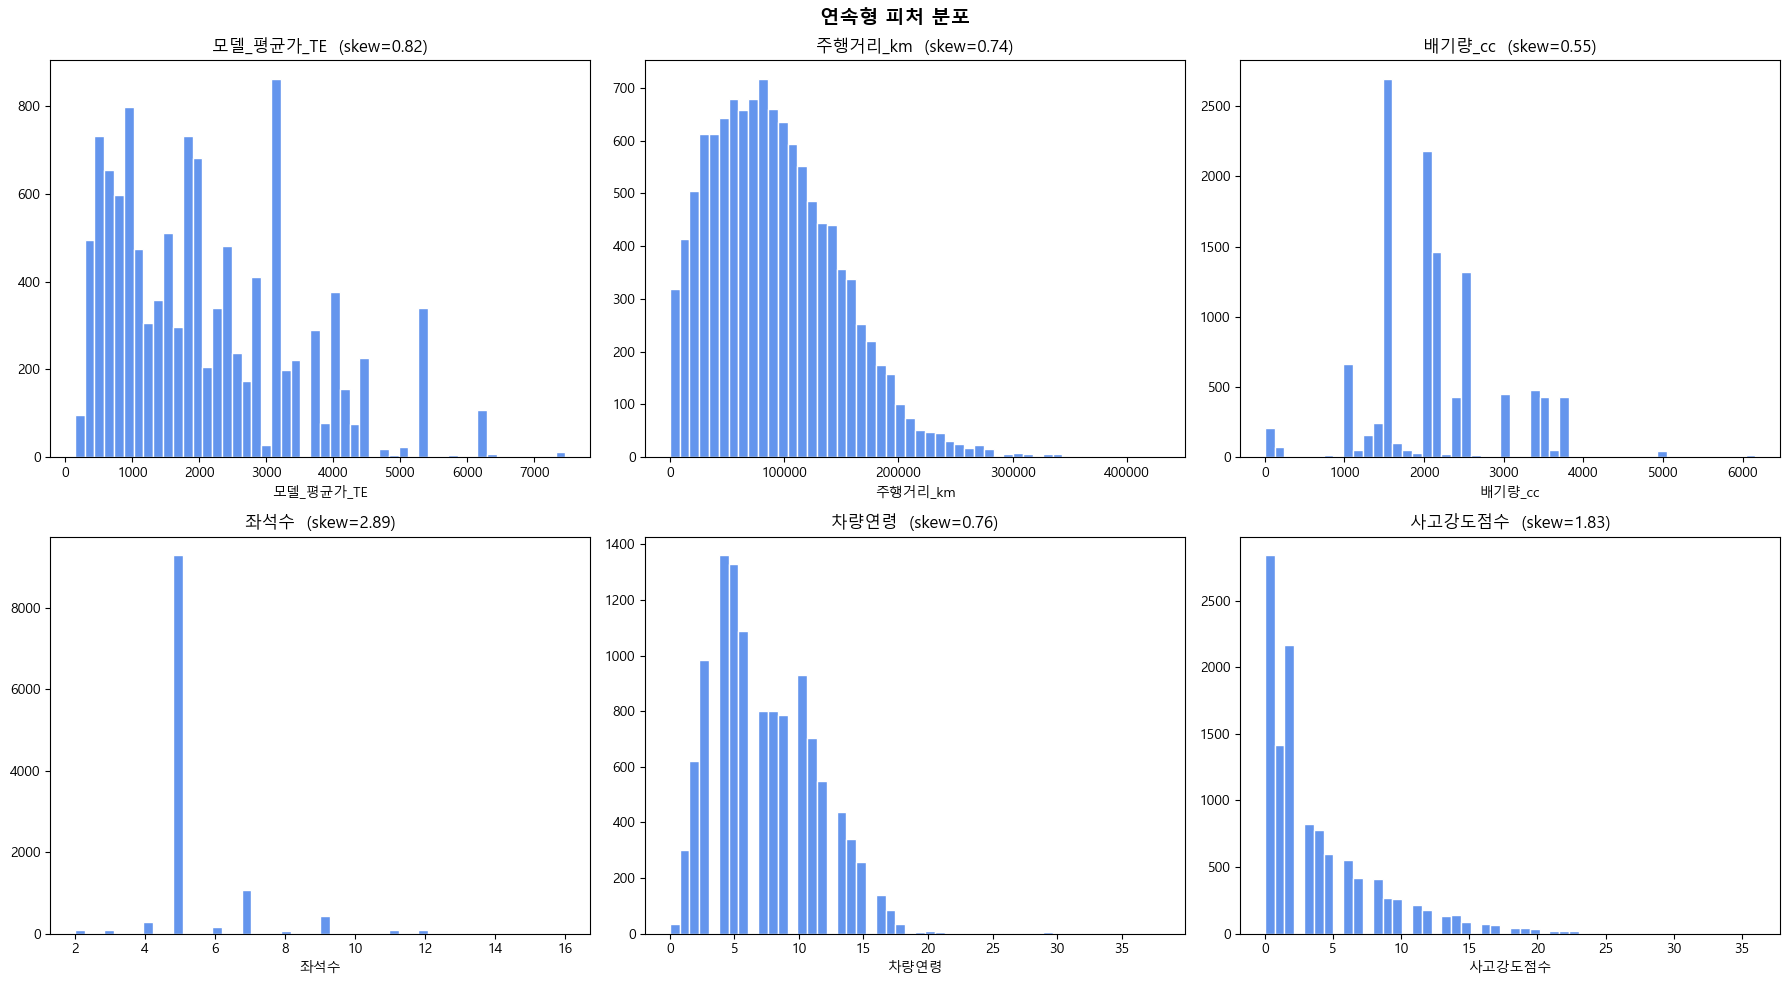

In [5]:
# 5. 연속형 피처 분포
plot_cols = [c for c in continuous_cols if c != target]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=50, color='cornflowerblue', edgecolor='white')
    axes[i].set_title(f'{col}  (skew={df[col].skew():.2f})')
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('연속형 피처 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

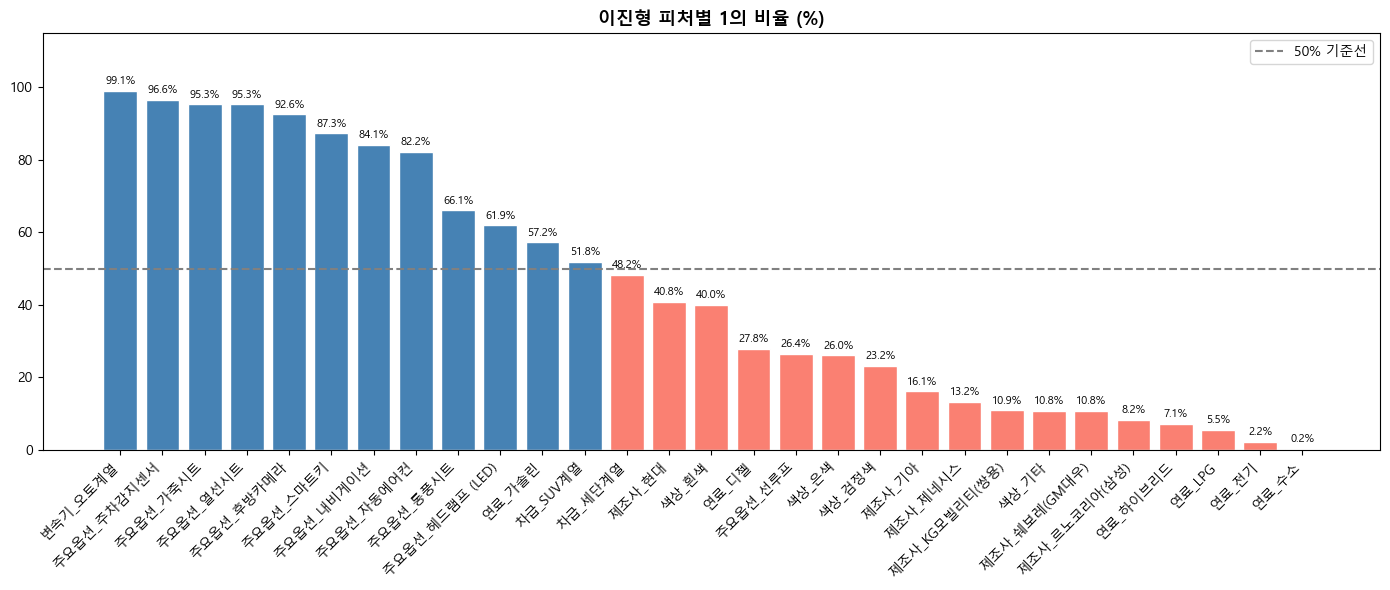

In [6]:
# 6. 이진형 피처 비율 (1의 비율 %)
binary_ratio = (df[binary_cols].mean() * 100).sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue' if v >= 50 else 'salmon' for v in binary_ratio.values]
bars = ax.bar(binary_ratio.index, binary_ratio.values, color=colors, edgecolor='white')
ax.axhline(50, color='gray', linestyle='--', label='50% 기준선')
ax.set_title('이진형 피처별 1의 비율 (%)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, binary_ratio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

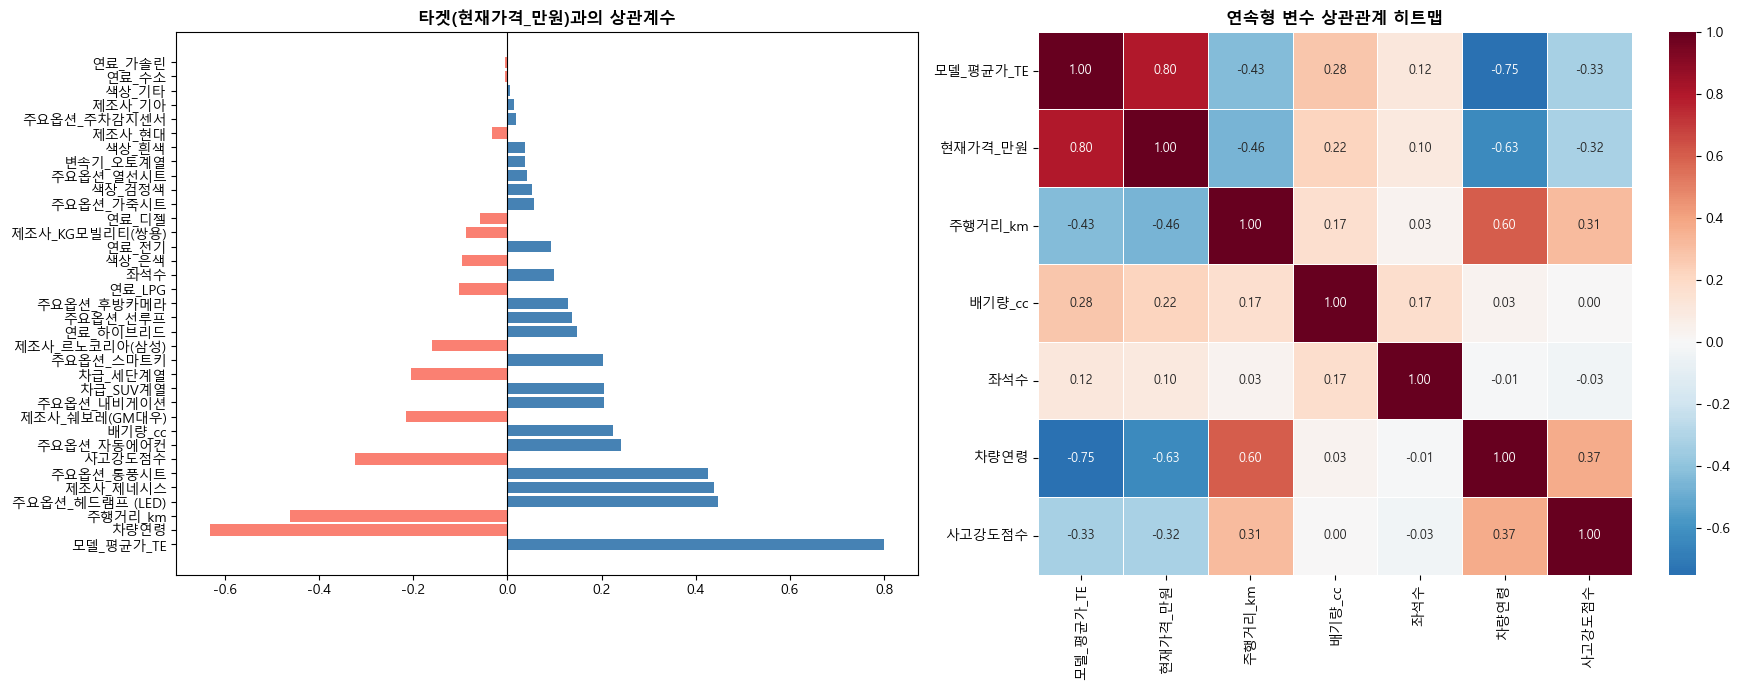

In [7]:
# 7. 타겟과의 상관관계
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].drop(columns=['매물ID']).corr()[target].drop(target)
corr_sorted = corr.abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 상관계수 바 차트
colors_c = ['steelblue' if v >= 0 else 'salmon' for v in corr[corr_sorted.index].values]
axes[0].barh(corr_sorted.index, corr[corr_sorted.index].values, color=colors_c)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'타겟({target})과의 상관계수', fontsize=12, fontweight='bold')

# 연속형 히트맵
sns.heatmap(df[continuous_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('연속형 변수 상관관계 히트맵', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

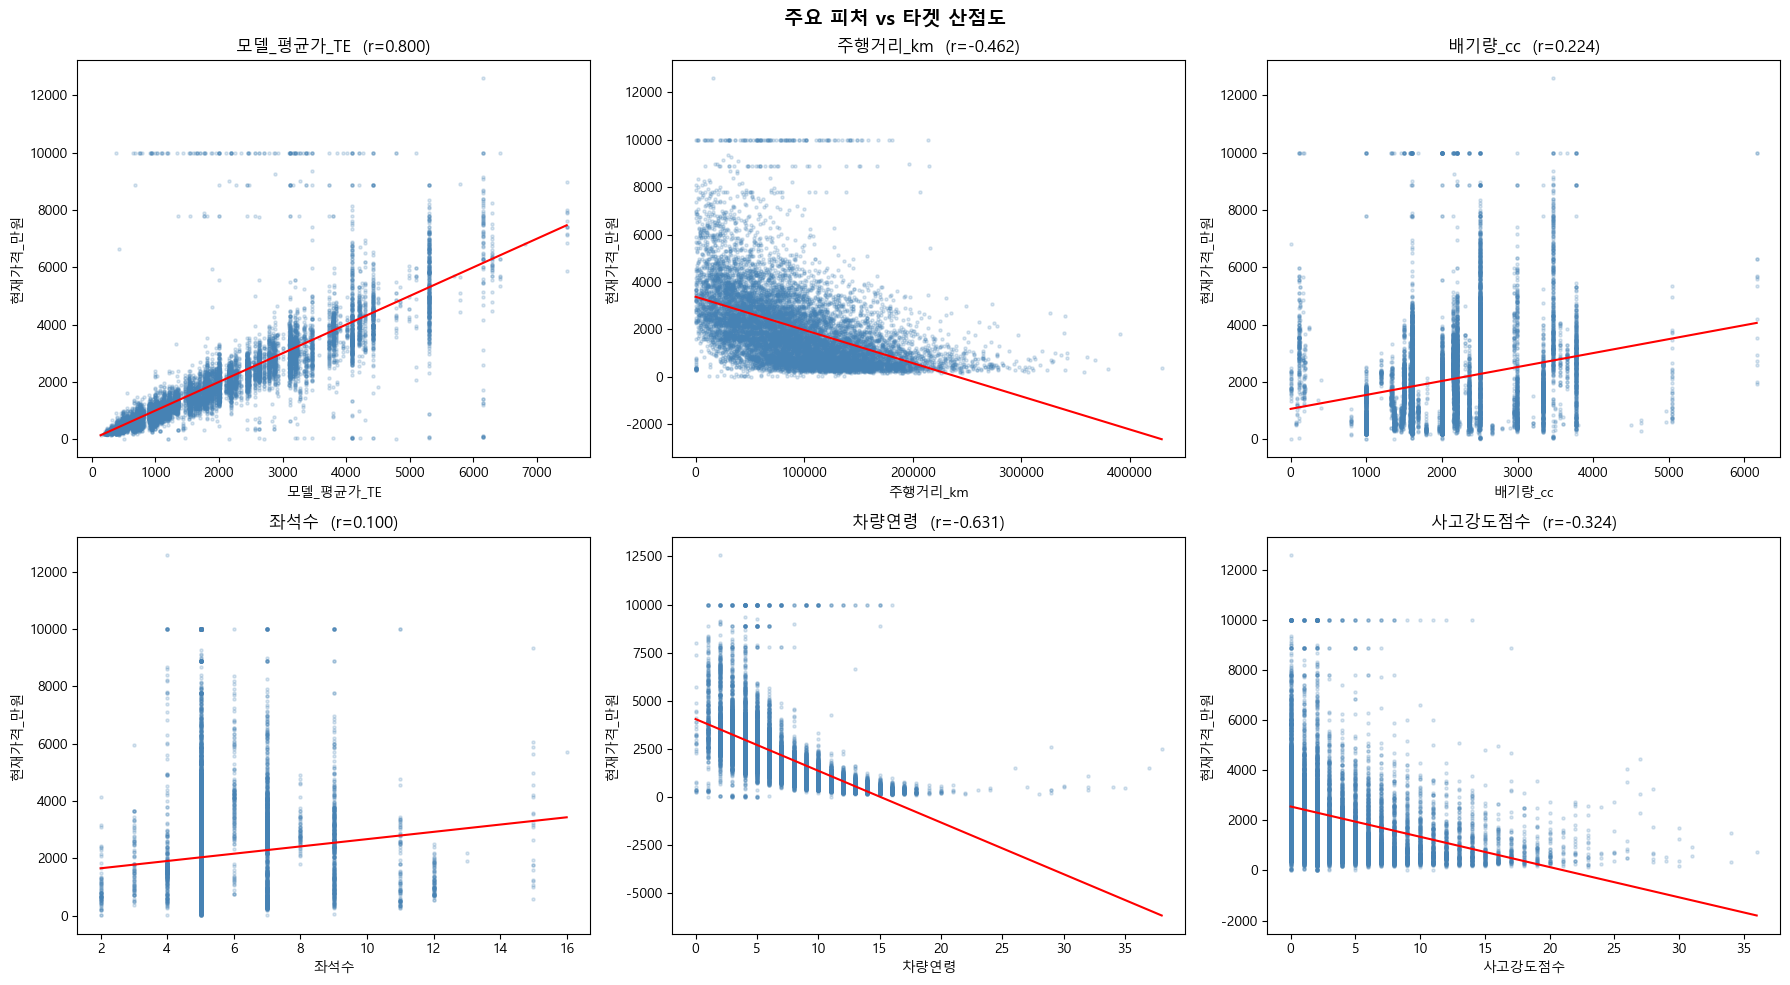

In [8]:
# 8. 주요 피처 vs 타겟 산점도
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].scatter(df[col], df[target], alpha=0.2, s=5, color='steelblue')
    z = np.polyfit(df[col], df[target], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=1.5)
    r = df[[col, target]].corr().iloc[0, 1]
    axes[i].set_title(f'{col}  (r={r:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('주요 피처 vs 타겟 산점도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# 9. 이상치 탐지 (IQR 기준)
outlier_summary = []
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({
        '컬럼': col,
        '하한': round(Q1 - 1.5*IQR, 1),
        '상한': round(Q3 + 1.5*IQR, 1),
        '이상치수': n_out,
        '이상치(%)': round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary).sort_values('이상치수', ascending=False).reset_index(drop=True)

,컬럼,하한,상한,이상치수,이상치(%)
0,좌석수,5.0,5.0,2334,20.09
1,사고강도점수,-6.5,13.5,581,5.00
2,현재가격_만원,-2127.5,5756.5,453,3.90
3,배기량_cc,249.5,3845.5,339,2.92
4,주행거리_km,-68751.0,245865.0,134,1.15
5,차량연령,-5.0,19.0,35,0.30
6,모델_평균가_TE,-2337.4,6389.3,20,0.17


## EDA 분석 결과 해석

### 1. 데이터 기본 현황
- **11,617행 × 38열**, 결측치 없음 → 전처리가 잘 된 깔끔한 데이터

---

### 2. 타겟 변수 (현재가격_만원)

| 지표 | 값 |
|---|---|
| 평균 | 2,083만원 |
| 중앙값 | 1,679만원 |
| 최솟값 | 1만원 |
| 최댓값 | 12,590만원 |
| 왜도 | **1.89** |

- 평균 > 중앙값 → **오른쪽 꼬리 분포** (고가 차량이 평균을 끌어올림)
- 왜도 1.89는 상당히 높음 → **로그 변환 적용이 필요**
- 로그 변환 후 왜도가 크게 줄어드는 것 확인됨 → 모델링 시 `log1p(가격)` 타겟 사용 권장

---

### 3. 연속형 피처

| 피처 | 주요 특징 |
|---|---|
| **모델_평균가_TE** | skew 0.82, 타겟과 거의 동일한 분포 |
| **주행거리_km** | skew 0.74, 비교적 정규분포에 가까움 |
| **차량연령** | skew 0.76, 대부분 5~10년 사이 집중 |
| **배기량_cc** | skew 0.55, 1600·2000·2200cc 구간에 군집 |
| **좌석수** | skew 2.89 → 5인승이 압도적 다수, 이상치로 잡힌 2,334개는 사실 버스·승합차 등 정상값 |
| **사고강도점수** | skew 1.83, 0점(무사고)에 집중, 오른쪽 꼬리 |

---

### 4. 이진형 피처 비율

**거의 모든 차량에 있는 옵션 (90%+)**
- 변속기_오토계열(99%), 주차감지센서(97%), 가죽시트·열선시트(95%), 후방카메라(93%)
- → **분산이 너무 낮아 모델 기여도가 거의 없을 가능성** → 추후 중요도 확인 필요

**균형 잡힌 피처 (40~60%)**
- 연료_가솔린(57%), 차급_SUV·세단계열(52:48)
- → **실질적인 분류 기여 가능**

**희소 피처 (5% 미만)**
- 연료_수소(0.2%), 연료_전기(2.2%)
- → 매물이 매우 적어 모델 학습에 거의 영향 없음

---

### 5. 상관관계 (타겟 기준)

**강한 양의 상관**
- `모델_평균가_TE` **r=0.80** → 압도적 1위, Target Encoding의 효과
- `헤드램프(LED)` r=0.45, `제조사_제네시스` r=0.44, `통풍시트` r=0.43

**강한 음의 상관**
- `차량연령` **r=-0.63** → 오래될수록 가격 하락, 당연하지만 중요한 피처
- `주행거리_km` r=-0.46 → 많이 탈수록 가격 하락

**약한 상관 (주의)**
- `변속기_오토계열`, `주차감지센서`, `후방카메라` 등 → 거의 모든 차량에 있어서 상관관계 낮음

---

### 6. 이상치

| 컬럼 | 이상치 수 | 해석 |
|---|---|---|
| 좌석수 | 2,334개(20%) | 승합·버스 등 정상값, 제거 불필요 |
| 사고강도점수 | 581개(5%) | 중대사고 차량, 실제 이상치 가능성 있음 |
| 현재가격_만원 | 453개(3.9%) | 고가 수입·제네시스 등, 실제 데이터일 가능성 높음 |
| 배기량_cc | 339개(2.9%) | 대형·수입차, 확인 필요 |

---

### 7. 종합 시사점 & 모델링 제언

| 항목 | 권장 사항 |
|---|---|
| 타겟 변환 | `log1p(현재가격_만원)` 사용 후 역변환 |
| 핵심 피처 | `모델_평균가_TE`, `차량연령`, `주행거리_km` 3개가 지배적 |
| 분산 낮은 피처 | 변속기_오토계열, 후방카메라 등 → 중요도 낮을 가능성, 모델 학습 후 확인 |
| 이상치 처리 | 좌석수 이상치는 보존, 가격·사고강도 이상치는 상한 클리핑 고려 |
| 다음 단계 | 피처 중요도 확인 후 불필요 피처 제거 |

---

# Phase 2 — 전처리

In [10]:
# ============================================================
# 2단계: 데이터 전처리
# ============================================================

# 1. 피처 / 타겟 분리
DROP_COLS = ['매물ID', '모델']   # ID·문자열 제거
TARGET = '현재가격_만원'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\n피처 목록:\n{list(X.columns)}")

X shape: (11617, 35)
y shape: (11617,)

피처 목록:
['모델_평균가_TE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


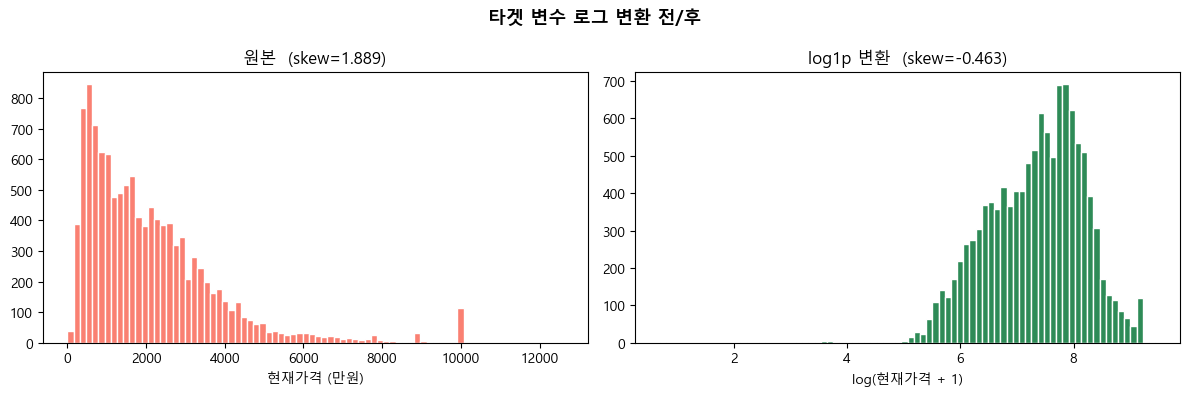

In [11]:
# 2. 타겟 로그 변환 (왜도 1.89 → log1p 적용)
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=80, color='salmon', edgecolor='white')
axes[0].set_title(f'원본  (skew={y.skew():.3f})')
axes[0].set_xlabel('현재가격 (만원)')

axes[1].hist(y_log, bins=80, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p 변환  (skew={y_log.skew():.3f})')
axes[1].set_xlabel('log(현재가격 + 1)')

plt.suptitle('타겟 변수 로그 변환 전/후', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# 3. 분산 낮은 피처 제거 (EDA에서 확인된 90% 이상 편향 피처)
from sklearn.feature_selection import VarianceThreshold

# 이진 피처만 분산 체크
binary_cols = [c for c in X.columns if X[c].nunique() == 2]
vt = VarianceThreshold(threshold=0.03)   # 약 97:3 이상 편향이면 제거
vt.fit(X[binary_cols])

removed = [c for c, s in zip(binary_cols, vt.get_support()) if not s]
print(f"제거 대상 피처 ({len(removed)}개): {removed}")

제거 대상 피처 (3개): ['연료_전기', '연료_수소', '변속기_오토계열']


In [13]:
# 제거 여부 확인 후 적용 (직접 확인 후 결정)
X_cleaned = X.drop(columns=removed)
print(f"전처리 후 피처 수: {X.shape[1]}개 → {X_cleaned.shape[1]}개")
print(f"남은 피처 목록:\n{list(X_cleaned.columns)}")

전처리 후 피처 수: 35개 → 32개
남은 피처 목록:
['모델_평균가_TE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '차급_SUV계열', '차급_세단계열']


In [14]:
# 4. 학습 / 테스트 분리 (8:2)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_log,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape}  /  Test: {X_test.shape}")
print(f"y_train 범위: {y_train.min():.2f} ~ {y_train.max():.2f}")
print(f"y_test  범위: {y_test.min():.2f} ~ {y_test.max():.2f}")

Train: (9293, 32)  /  Test: (2324, 32)
y_train 범위: 2.20 ~ 9.21
y_test  범위: 0.69 ~ 9.44


In [15]:
# 5. 스케일링 (선형 모델용)
#    트리 계열은 스케일링 불필요 → 선형 모델 전용으로 별도 보관
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train 기준으로 fit
X_test_scaled  = scaler.transform(X_test)         # test는 transform만

print("스케일링 완료")
print(f"  평균(train 기준): {X_train_scaled.mean(axis=0).round(2)[:5]} ...")
print(f"  표준편차(train):  {X_train_scaled.std(axis=0).round(2)[:5]} ...")

스케일링 완료
  평균(train 기준): [-0.  0. -0.  0. -0.] ...
  표준편차(train):  [1. 1. 1. 1. 1.] ...


In [16]:
# 6. 평가 함수 정의 (전 모델 공통 사용)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model_name, y_true_log, y_pred_log):
    """log 변환된 예측값을 원래 단위로 역변환 후 평가"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'='*45}")
    print(f"  [{model_name}] 평가 결과")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:>10,.1f} 만원")
    print(f"  MAE  : {mae:>10,.1f} 만원")
    print(f"  MAPE : {mape:>10.2f} %")
    print(f"  R²   : {r2:>10.4f}")

    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

results = []   # 모델별 결과 누적 저장
print("✅ 전처리 완료! 베이스라인 모델 준비 완료")

✅ 전처리 완료! 베이스라인 모델 준비 완료


**전처리 흐름 요약**

| 단계 | 내용 |
|---|---|
| 피처/타겟 분리 | `매물ID`, `모델` 제거 |
| 타겟 변환 | `log1p` 적용, 예측 후 `expm1` 역변환 |
| 피처 제거 | 분산 낮은 이진 피처 (threshold=0.03) |
| 데이터 분할 | Train 80 / Test 20, random_state=42 |
| 스케일링 | 선형 모델용 StandardScaler (트리 계열 불필요) |
| 평가 함수 | RMSE / MAE / MAPE / R² (원래 단위로 역변환) |

# Phase 3 — 베이스라인 모델


  [Linear Regression] 평가 결과
  RMSE :    1,023.9 만원
  MAE  :      388.8 만원
  MAPE :     230.19 %
  R²   :     0.6488


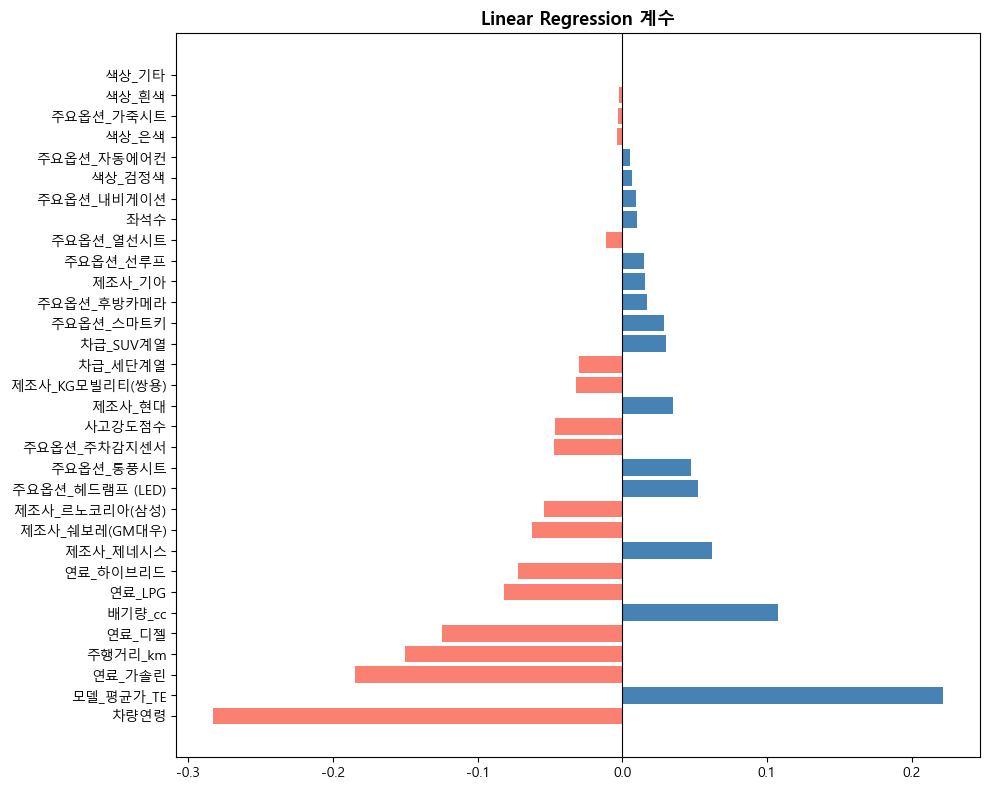


  [Ridge (alpha=10)] 평가 결과
  RMSE :    1,023.5 만원
  MAE  :      388.5 만원
  MAPE :     228.93 %
  R²   :     0.6490

  [Lasso (alpha=0.001)] 평가 결과
  RMSE :    1,022.1 만원
  MAE  :      386.6 만원
  MAPE :     220.20 %
  R²   :     0.6500
Lasso가 0으로 만든 피처 (3개):
['제조사_기아', '색상_흰색', '색상_기타']

  [Random Forest] 평가 결과
  RMSE :      988.9 만원
  MAE  :      339.0 만원
  MAPE :     214.89 %
  R²   :     0.6724


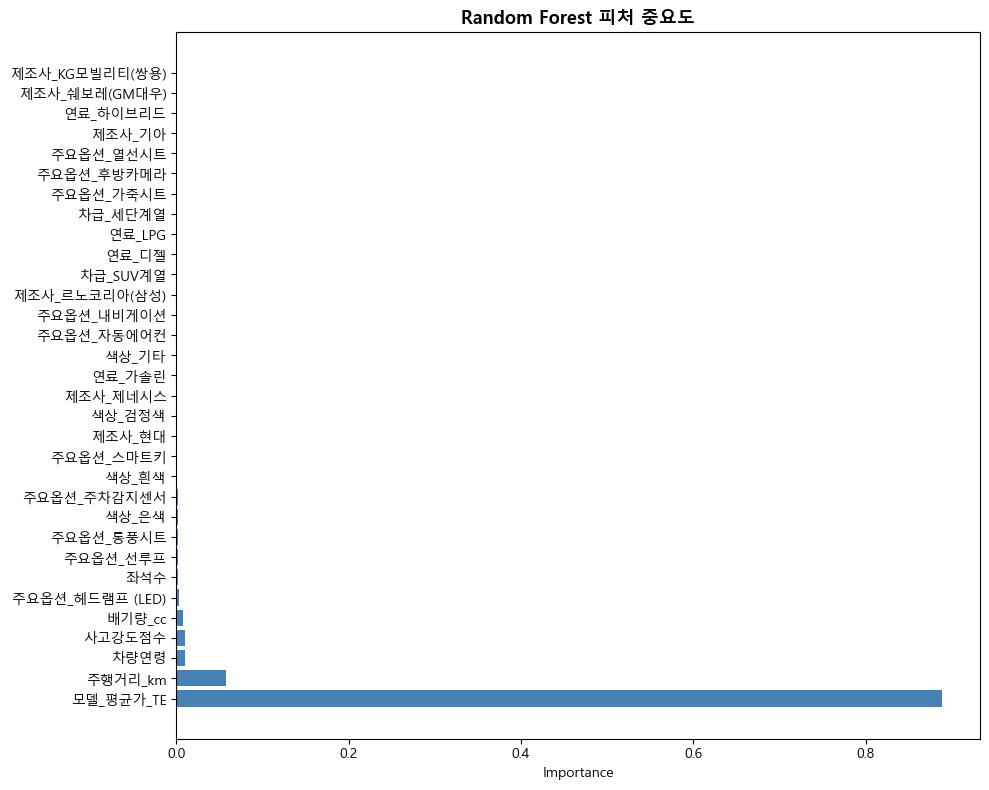

[0]	validation_0-rmse:0.83930
[100]	validation_0-rmse:0.38101
[200]	validation_0-rmse:0.38245
[300]	validation_0-rmse:0.38482
[400]	validation_0-rmse:0.38839
[499]	validation_0-rmse:0.39157

  [XGBoost] 평가 결과
  RMSE :    1,017.2 만원
  MAE  :      351.0 만원
  MAPE :     200.96 %
  R²   :     0.6534
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 9293, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 7.318502
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

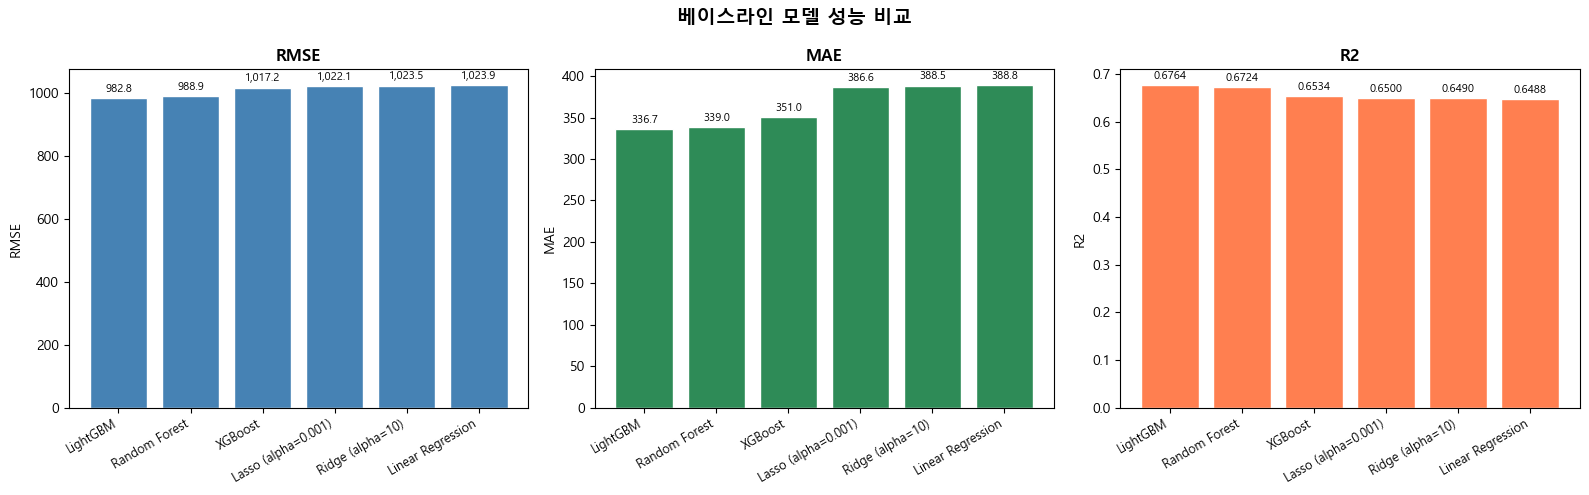

In [17]:
# ============================================================
# 3단계: 베이스라인 모델
# ============================================================

# 공통 라이브러리
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb


### Step 1. Linear Regression

# Linear Regression (스케일링된 데이터 사용)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

result_lr = evaluate("Linear Regression", y_test, y_pred_lr)
results.append(result_lr)


# 계수 시각화 (어떤 피처가 영향을 미치는지 확인)
coef_df = pd.DataFrame({
    '피처': X_train.columns,
    '계수': lr.coef_
}).sort_values('계수', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if v >= 0 else 'salmon' for v in coef_df['계수']]
ax.barh(coef_df['피처'], coef_df['계수'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression 계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 2. Ridge / Lasso

# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

result_ridge = evaluate("Ridge (alpha=10)", y_test, y_pred_ridge)
results.append(result_ridge)


# Lasso
lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

result_lasso = evaluate("Lasso (alpha=0.001)", y_test, y_pred_lasso)
results.append(result_lasso)


# Lasso 제거 피처 확인 (계수=0이 된 피처)
lasso_coef = pd.Series(lasso.coef_, index=X_train.columns)
zeroed = lasso_coef[lasso_coef == 0].index.tolist()
print(f"Lasso가 0으로 만든 피처 ({len(zeroed)}개):\n{zeroed}")


### Step 3. Random Forest


# Random Forest (스케일링 불필요 → 원본 사용)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

result_rf = evaluate("Random Forest", y_test, y_pred_rf)
results.append(result_rf)


# 피처 중요도 시각화
fi_rf = pd.Series(rf.feature_importances_, index=X_train.columns)
fi_rf = fi_rf.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi_rf.index, fi_rf.values, color='steelblue')
ax.set_title('Random Forest 피처 중요도', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### Step 4. XGBoost / LightGBM


# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=100)
y_pred_xgb = xgb_model.predict(X_test)

result_xgb = evaluate("XGBoost", y_test, y_pred_xgb)
results.append(result_xgb)


# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)])
y_pred_lgb = lgb_model.predict(X_test)

result_lgb = evaluate("LightGBM", y_test, y_pred_lgb)
results.append(result_lgb)


### 최종 성능 비교


# 전체 모델 성능 비교표
result_df = pd.DataFrame(results).set_index('model')
result_df = result_df.sort_values('RMSE')
print(result_df.round(2))


# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors  = ['steelblue', 'seagreen', 'coral']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(result_df.index, result_df[metric], color=color, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, result_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.1f}' if metric != 'R2' else f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('베이스라인 모델 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**실행 순서 요약**


Linear → Ridge → Lasso → Random Forest → XGBoost → LightGBM
                                    ↑
                          피처 중요도 먼저 확인 후
                          XGBoost/LightGBM 진행 권장
